In [35]:
import torch

torch.cuda.empty_cache()

In [36]:
# -*- coding: utf-8 -*-
from dreal import *
# from Functions import *
import torch 
import torch.nn.functional as F
import numpy as np
import timeit 
import matplotlib.pyplot as plt
import torch.nn as nn
import random

import matplotlib.patches as patches
from matplotlib import cm

In [37]:
torch.manual_seed(42)

random.seed()



In [38]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [39]:
numerical_x = torch.Tensor(500, 2).uniform_(-6, 6).float()
numerical_x = numerical_x.to(device)  

In [40]:
def checkSMTconstraints(vars,a_learnt,divergence_learnt, ball_lb, ball_ub, config, epsilon=0):
    """ Check the SMT constraints for the given variables and learnt parameters. """
    ball = Expression(0)

    # construct ball constraint
    for i in range(len(vars)):
        ball += vars[i]**2
    ball_in_bound = logical_and(ball >= ball_lb, ball <= ball_ub)

    # condition on a
    a_condition = a_learnt >= 0
    divergence_condition = divergence_learnt > 0
    stability_condition = logical_and(
        logical_imply(ball_in_bound, divergence_condition),
        logical_imply(ball_in_bound, a_condition)
    )

    # check satisfiability of the negation of the condition
    return CheckSatisfiability(logical_not(stability_condition), config)


def AddCounterexamples(x, CE, N, device):
    """
    Adds counterexamples to the sample set `x`.
    
    Args:
        x: Existing tensor of samples.
        CE: Counterexample intervals from `Checkdivergence`.
        N: Number of nearby points to add for each counterexample.
        device: Device where tensors are stored (e.g., `cuda:1`).

    Returns:
        Updated tensor with counterexamples added.
    """
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)  # Generate nearby points
        nearby.append(nearby_)
    
    for i in range(N):
        n_pt = []
        for j in range(x.shape[1]):
            n_pt.append(nearby[j][i])  # Collect one point from each dimension
        # Add the point to `x` on the correct device
        n_pt_tensor = torch.tensor([n_pt], dtype=torch.float32, device=device)
        x = torch.cat((x, n_pt_tensor), dim=0)
        x= torch.unique(x, dim=0)

    return x, n_pt_tensor

# Dynamical system:
The system of interest is:
\begin{align*}
    \begin{bmatrix}
        \dot{x}_1 \\
        \dot{x}_2
    \end{bmatrix}= 
    \begin{bmatrix}
        x_2-x_1^3+x_1^2\\
        0
    \end{bmatrix} + \begin{bmatrix}
        0\\
        1
    \end{bmatrix}u
\end{align*}


In [41]:
import math

def f_value(f_val, g_val, u):
    """
    The dynamical system is defined as f(x)+g(x)u
    where f(x) and g(x) are functions of x and u is the control
    input. This function returns the value of the dynamical system
    at x with control input u.
    """
    return f_val + g_val * u

def f(x):
    # fill this later according to dynamical system
    # ensure the return is like torch.tensor([1,2])
    val = torch.tensor([x[1]-x[0]**3+x[0]**2, 0],device=device)
    return val
def g(x):
    # fill this later according to dynamical system
    # ensure the return is like torch.tensor([1,2])
    return torch.tensor([0*x[0], 1], device=device)



In [42]:
class polynomial_net(nn.Module):
    """ this class is used to define the neural network which we intent to approximate a polynomial function"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class polynomial_net_bias_Zero(nn.Module):
    """ this class is used to define the neural network which we intent to approximate a polynomial function"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net_bias_Zero, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)  # set bias to zero
                layer.bias.requires_grad = False  # freeze bias to stay zero


    def forward(self, x):
        return self.net(x)
    
class numerator_polynomial_net(nn.Module):
    """ this class is used to define the neural network which we intent to approximate a polynomial function"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(numerator_polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class FixedDenominatorNet(nn.Module):
    def __init__(self):
        super(FixedDenominatorNet, self).__init__()

    def forward(self, x):
        # Compute e^{||x||^2}
        norm_squared = torch.sum(x ** 2, dim=1, keepdim=True)  
        return torch.exp(norm_squared)
     
class GammaFunctionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GammaFunctionNet, self).__init__()
        self.linear_layer = nn.Linear(input_dim, output_dim)
        
        # Initialize weights to zero and bias to zero (or any desired value)
        nn.init.constant_(self.linear_layer.weight, 0)
        nn.init.constant_(self.linear_layer.bias, 0)

        # Freeze weights to ensure they cannot be updated
        self.linear_layer.weight.requires_grad = False

    def forward(self, x):
        # Directly return the bias as output
        return self.linear_layer.bias



In [43]:
def gradient_at_given_function(func,x):
    """ The function returns the gradient of given function at x"""
    # Ensure x requires gradients
    x = x.clone().detach().requires_grad_(True)
    
   # Compute the output of the function
    output = func(x.unsqueeze(0))  # Add batch dimension (shape: [1, input_dim])
    
    # Extract scalar from output tensor
    output = output.squeeze()  # Remove batch and channel dimensions (shape: ())
    
    # Ensure the function returns a scalar
    if output.dim() != 0:
        raise ValueError(f"The function must return a scalar value, but got shape {output.shape}.")
    
    # Compute the gradient
    grad = torch.autograd.grad(outputs=output, inputs=x, create_graph=True)[0]
    
    return grad


def div_f(x):
    # fill this later according to dynamical system
    # ensure the return is like torch.tensor(1)
    term = -3*(x[0]**2 )+ 2*x[0]
    return torch.tensor(term, device=device)

def div_g(x):
    # fill this later according to dynamical system
    # ensure the return is like torch.tensor(1)
    term = 0
    return torch.tensor(term, device=device)

def control_density_risk(x, f_fun, g_fun, a_fun, b_fun, c_fun):
    ret_val = []
    for i in range(x.shape[0]):
        divergence_at_f = div_f(x[i])
        divergence_at_g = div_g(x[i])
        grad_at_a = gradient_at_given_function(a_fun, x[i])
        grad_at_c = gradient_at_given_function(c_fun, x[i])
        grad_at_b = gradient_at_given_function(b_fun, x[i])
        # square root of x^Tx
        
        a_vals = a_fun(x[i])
        b_vals = b_fun(x[i])
        c_vals = c_fun(x[i])
        f_vals = f_fun(x[i])
        g_vals = g_fun(x[i])
        term1 = a_vals * divergence_at_f + divergence_at_g * c_vals + grad_at_a.T @ f_vals + grad_at_c.T @ g_vals
        term2 = grad_at_b.T @ (f_vals * a_vals + g_vals * c_vals) 
        term1 = b_vals * term1
        term = term1 - term2
        ret_val.append(term)
    ret_val = torch.stack(ret_val)
    return ret_val 



In [44]:
def control_density_loss(x, f_fun, g_fun, a_fun, b_fun, c_fun, gamma_fun, lambda_center=1, lambda_decay=1):
    """
    Compute the control density loss with additional center and decay regularization.

    Args:
        x: Input tensor.
        f_fun: Function representing f(x).
        g_fun: Function representing g(x).
        a_fun: Function representing a(x).
        b_fun: Function representing b(x).
        c_fun: Function representing c(x).
        gamma_fun: Function representing gamma(x).
        lambda_center: Weight for center-maximizing term.
        lambda_decay: Weight for decay-penalizing term.

    Returns:
        Total control density loss value.
    """
    divergence = control_density_risk(x, f_fun, g_fun, a_fun, b_fun, c_fun)
    loss = F.relu(gamma_fun(x) - divergence).mean()
    rho = a_fun(x) / (b_fun(x) + 1e-6)
    a_loss = F.relu(-rho).mean()
    gamma_loss = F.relu(-gamma_fun(x)).mean()
      
    total_loss = loss + a_loss + gamma_loss 
    return total_loss


In [45]:
class activSymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights)):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # # Apply tanh activation
            # z = [tanh(zi) for zi in z]
            # Apply sigmoid activation
            z = [(1/(1 + exp(-zi))) for zi in z]
        
        # # Final linear layer without activation
        # z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out


In [46]:
class SymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights) - 1):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # Apply tanh activation
            z = [tanh(zi) for zi in z]
            # # Apply sigmoid activation
            # z = [(1/(1 + exp(-zi))) for zi in z]
        
        # Final linear layer without activation
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out


In [47]:
def candidate_constraint_learnt(vars,a_fun,b_fun,c_fun):
    """
    Construct candidate constraints for the learnt functions.
    
    Args:
        vars: List of dReal Variables
        a_fun: Function representing a(x).
        b_fun: Function representing b(x).
        c_fun: Function representing c(x).

    Returns:
        Symbolic expression for the candidate constraint.
    """
    a_sym = activSymbolicNN(a_fun).forward_symbolic(vars)[0]
    b_sym = SymbolicNN(b_fun).forward_symbolic(vars)[0]  # Add [0] here
    c_sym = SymbolicNN(c_fun).forward_symbolic(vars)[0]


    # write f and g in terms of val
    f_val = [vars[1]-vars[0]**3+vars[0]**2, 0]
    # print("f_val: ", f_val)
    g_val = [0*vars[0],1]
    # print("g_val: ", g_val)
    f_div = - 3 * (vars[0]**2) + 2 * vars[0]
    g_div = 0 
    grad_a = [a_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_c = [c_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_b = [b_sym.Differentiate(vars[i]) for i in range(len(vars))]

    constraint1 = a_sym * f_div + g_div * c_sym + sum([grad_a[i] * f_val[i] for i in range(len(f_val))]) + sum([grad_c[i] * g_val[i] for i in range(len(g_val))])
  
    constraint1 = b_sym * constraint1

    constraint2 = sum([grad_b[i] * (f_val[i] * a_sym + g_val[i] * c_sym) for i in range(len(f_val))])
    constraint = constraint1 - constraint2
    return a_sym , constraint


In [48]:
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-5
epsilon = 0

ball_lb = 0.5
ball_ub = 6
x1 = Variable("x1")
x2 = Variable("x2")


In [49]:
def train_density(x,epochs=2000, lr=1e-2):
    loss_total_density = []
    # Define the neural networks
    a_net = numerator_polynomial_net(2, 4, 1).to(device)
    c_net = polynomial_net(2, 4, 1).to(device)
    b_net = polynomial_net_bias_Zero(2, 4, 1).to(device)
    gamma_net = GammaFunctionNet(2, 1).to(device)

    # Define the optimizer
    optimizer = torch.optim.RMSprop(list(a_net.parameters()) + list(c_net.parameters()) + list(b_net.parameters()) + list(gamma_net.parameters()), lr=lr)

    valid = False
    print("Training density function")
    while not valid :
        for epoch in range(epochs):
            optimizer.zero_grad()
            # compute the loss
            loss = control_density_loss(x, f, g, a_net, b_net, c_net, gamma_net)
            loss_total_density.append(loss.item())
            # backpropagation
            loss.backward()
            # update the parameters
            optimizer.step()
            
            if loss.item() == 0:
                # # Check for counterexamples
                # vars = [Variable("x1"), Variable("x2")]
                # a_learnt, divergence_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
                # CE = checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config)
                # if (CE):
                #     print("Counterexample found!")
                #     x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
                # else:
                valid = True 
                print("No counterexample found.")
                break

            print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")
            if epoch % 100 == 0:
                # Check for counterexamples
                vars = [Variable("x1"), Variable("x2")]
                a_learnt, divergence_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
                CE = checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config)
                if (CE):
                    print("Counterexample found!")
                    x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
                else:
                    valid = True 
                    print("No counterexample found.")
                    break
    print(f"Final Loss: {loss.item():.4f}")
    print(f"The learned margin is {gamma_net(torch.tensor([0,0], dtype=torch.float32, device=device))}")
    return loss_total_density, a_net, b_net, c_net, gamma_net


In [50]:
def plot_results(risks, labels):
    plt.figure(figsize=(10, 6))
    for risk, label in zip(risks, labels):
        plt.plot(risk, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Risk")
    plt.title("Risk Over Iterations")
    plt.legend()
    plt.grid()
    plt.show()


In [51]:
loss_density, a_ret, b_ret, c_ret, gamma_net = train_density(numerical_x, epochs=2000, lr=1e-2)

Training density function


/tmp/ipykernel_166590/2363613575.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(term, device=device)


Epoch 0/2000, Loss: 4.3419
Counterexample found!
Epoch 1/2000, Loss: 3.8414
Epoch 2/2000, Loss: 4.3701
Epoch 3/2000, Loss: 3.6938
Epoch 4/2000, Loss: 2.8238
Epoch 5/2000, Loss: 2.1363
Epoch 6/2000, Loss: 1.9811
Epoch 7/2000, Loss: 1.5013
Epoch 8/2000, Loss: 1.4995
Epoch 9/2000, Loss: 1.9446
Epoch 10/2000, Loss: 1.6663
Epoch 11/2000, Loss: 1.4018
Epoch 12/2000, Loss: 1.2378
Epoch 13/2000, Loss: 1.1951
Epoch 14/2000, Loss: 1.1438
Epoch 15/2000, Loss: 5.7540
Epoch 16/2000, Loss: 1.0862
Epoch 17/2000, Loss: 1.0121
Epoch 18/2000, Loss: 0.9517
Epoch 19/2000, Loss: 0.9071
Epoch 20/2000, Loss: 0.8588
Epoch 21/2000, Loss: 0.8106
Epoch 22/2000, Loss: 0.7723
Epoch 23/2000, Loss: 0.7389
Epoch 24/2000, Loss: 0.7080
Epoch 25/2000, Loss: 0.6806
Epoch 26/2000, Loss: 0.6482
Epoch 27/2000, Loss: 0.6162
Epoch 28/2000, Loss: 0.5798
Epoch 29/2000, Loss: 0.5529
Epoch 30/2000, Loss: 0.5329
Epoch 31/2000, Loss: 0.5060
Epoch 32/2000, Loss: 0.4807
Epoch 33/2000, Loss: 0.4563
Epoch 34/2000, Loss: 0.4420
Epoch 35

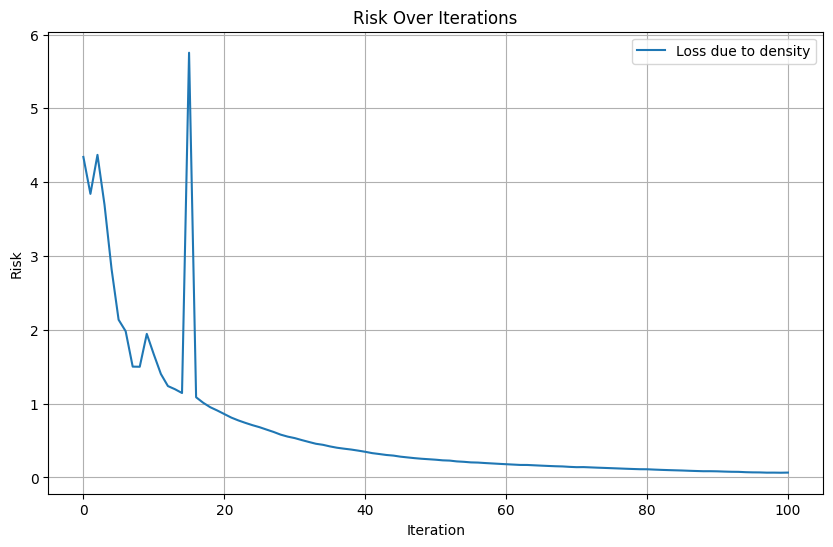

In [52]:

risks = []
risks.append(loss_density)

plot_results(risks, labels=[f"Loss due to {d}" for d in ['density']])


In [53]:
grid_size = 100
# Define grid for x1 and x2
x1 = torch.linspace(-6, 6, grid_size)
x2 = torch.linspace(-6, 6, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2)
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel()], dim=1).to(device)


/home/sahilc/miniconda3/envs/dreal_env/lib/python3.8/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [54]:
rho_set = a_ret(grid_points)/ (b_ret(grid_points) + 1e-6)


# # Compute violations set: element-wise min of rho_set and divergence_set
# violations_set = torch.minimum(rho_set, divergence_set)
violations_set = rho_set
# # Convert to binary values: 1 for violation, -1 for satisfaction
# violations_set = torch.where(violations_set <= 0, 1, -1)

# Move to CPU and convert to NumPy for visualization
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)


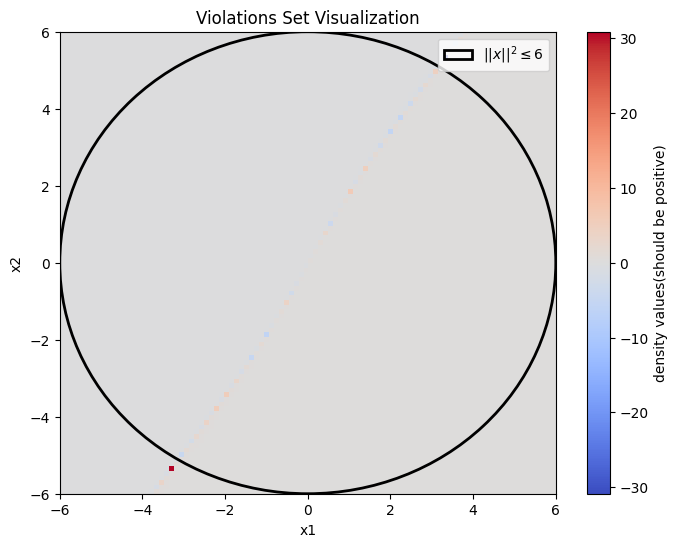

In [55]:
import matplotlib.patches as patches

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    violations_set,
    extent=[-6, 6, -6, 6],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="density values(should be positive)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Violations Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 6, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


/tmp/ipykernel_166590/2363613575.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(term, device=device)


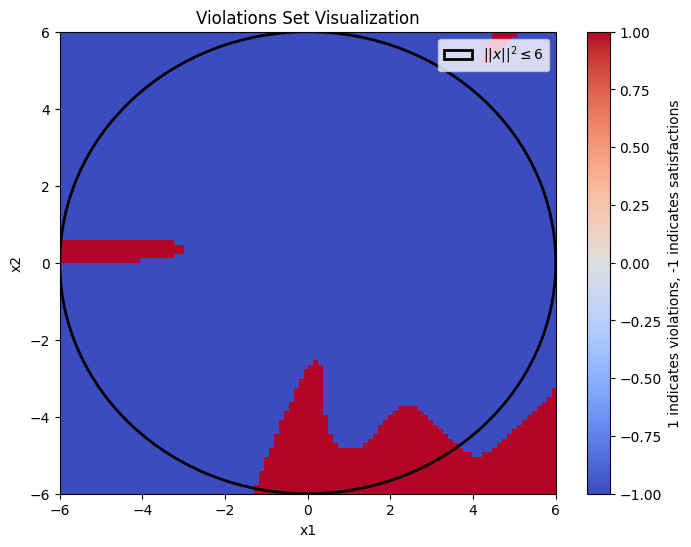

In [56]:
divergence_set = control_density_risk(grid_points, f, g, a_ret, b_ret, c_ret)

violations_set = divergence_set
# # Convert to binary values: 1 for violation, -1 for satisfaction
violations_set = torch.where(violations_set <= 0, 1, -1)

# Move to CPU and convert to NumPy for visualization
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)





# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    violations_set,
    extent=[-6, 6, -6, 6],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="1 indicates violations, -1 indicates satisfactions")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Violations Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 6, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [58]:
def plot_density_countours(a_nn, b_nn, c_nn, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set = a_nn(grid_points) / ((b_nn(grid_points)) + 1e-6)
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    # contours = ax.contour(X, Y, rho_set, levels=10, colors='k')
    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3,cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            u_values = c_nn(flow_points) / a_nn(flow_points)
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('Angle (rad)')
    ax.set_ylabel('Angular velocity')
    ax.set_title('Density Function Contours with Flow Field')
    ax.legend()
    ax.grid(True)
    
    plt.show()
    
    return fig, ax





    

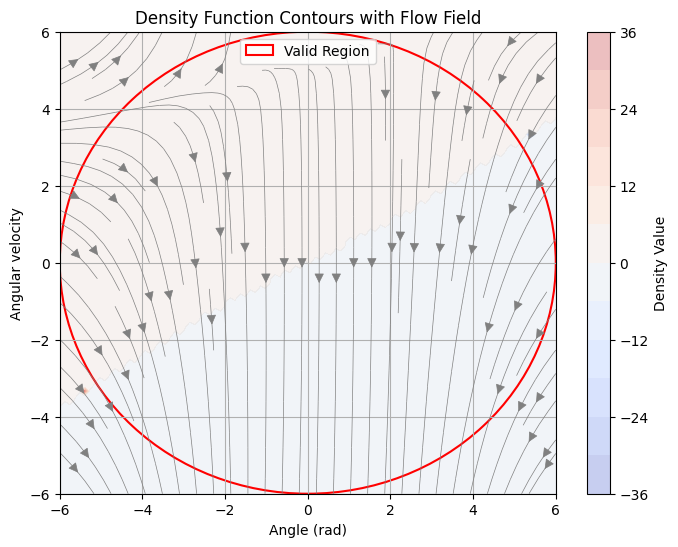

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Density Function Contours with Flow Field'}, xlabel='Angle (rad)', ylabel='Angular velocity'>)

In [59]:

# Call the function to plot density contours and flow field
plot_density_countours(a_ret, b_ret, c_ret, device, plot_flow=True)

